## Assignment 3: Pattern Mining and Recommender Systems

### Aryan Moradi, A1779263, Version 04

In [52]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from collections import defaultdict
from itertools import combinations
from datetime import datetime, timedelta

In [53]:
train_path = 'Groceries data train.csv'
test_path  = 'Groceries data test.csv'
train_df  = pd.read_csv(train_path)
test_df   = pd.read_csv(test_path)

# Exploratory Data Analysis (EDA)

In [54]:
train_df = train_df.rename(columns={"User_id": "user_id"})

In [55]:
train_df["Date"] = pd.to_datetime(train_df["Date"], format='%d/%m/%Y')

test_df["Date"] = pd.to_datetime(test_df["Date"], format='%d/%m/%Y')

In [56]:
print("Train shape:", train_df.shape)
print("Test  shape:", test_df.shape)
print("\nColumns:", list(train_df.columns))
print("\nMissing values (train):\n", train_df.isna().sum())
print("\nMissing values (test):\n", test_df.isna().sum())

Train shape: (19382, 7)
Test  shape: (19383, 7)

Columns: ['user_id', 'Date', 'itemDescription', 'year', 'month', 'day', 'day_of_week']

Missing values (train):
 user_id            0
Date               0
itemDescription    0
year               0
month              0
day                0
day_of_week        0
dtype: int64

Missing values (test):
 user_id            0
Date               0
itemDescription    0
year               0
month              0
day                0
day_of_week        0
dtype: int64


We first fix the inconsistency of the column name for train and test datasets. The we see that both datasets are very similar in size, 19.4k rows and 7 columns. No missing values were detected, so no immediate cleaning is required. We also parse the value of the Date column to appropriate type to be able work with it easily later on. Each row appears to represent a single item purchased by a user on a specific date so potentially we might need to consolidate all the user specific purchases on the specific date together in one row if need be.

In [57]:
train_daily = train_df.groupby('Date').size().reset_index(name='Transactions')
test_daily = test_df.groupby('Date').size().reset_index(name='Transactions')


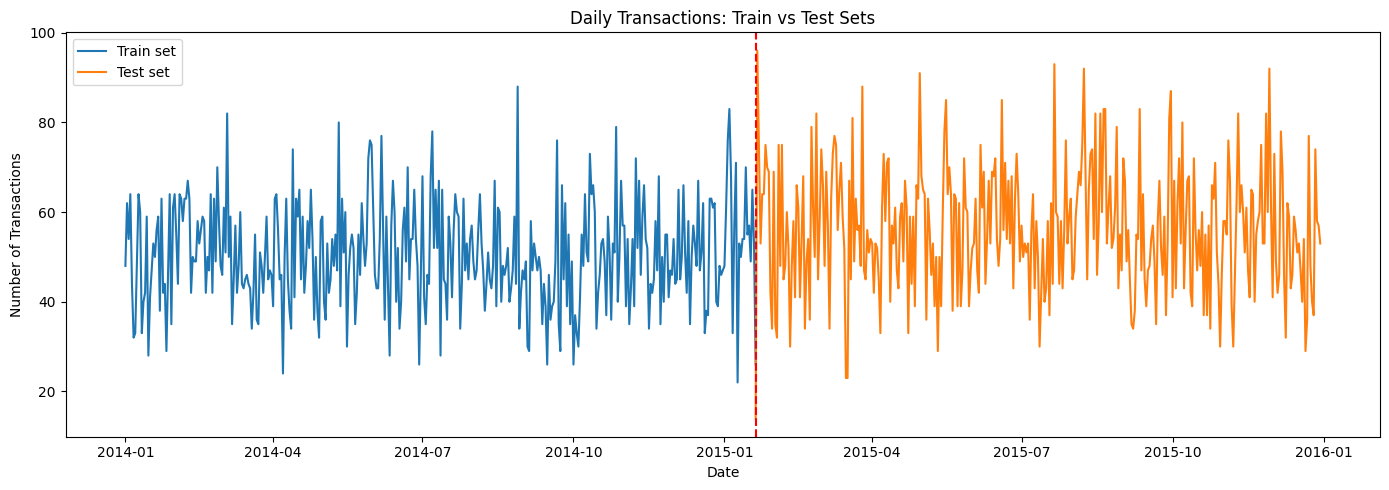

In [58]:
plt.figure(figsize=(14, 5))
plt.plot(train_daily['Date'], train_daily['Transactions'], label='Train set')
plt.plot(test_daily['Date'], test_daily['Transactions'], label='Test set')

plt.title('Daily Transactions: Train vs Test Sets')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.legend()
plt.axvline(x=test_daily['Date'].min(), color='r', linestyle='--', label='Train/Test Split')
plt.tight_layout()
plt.show()

We then generate the joint transaction vs date plot of train and test datasets to have general idea of how everything looks throughout the timeline. Sales volume is relatively stable week‑to‑week with mild seasonality. The 2014 series shows two noticeable dips around late April and late December, likely holiday effects. 2015 follows a similar baseline, which could mean the two datasets are comparable for modelling. 

In [59]:
top20_train = train_df["itemDescription"].value_counts().head(20)
top20_test  = test_df["itemDescription"].value_counts().head(20)

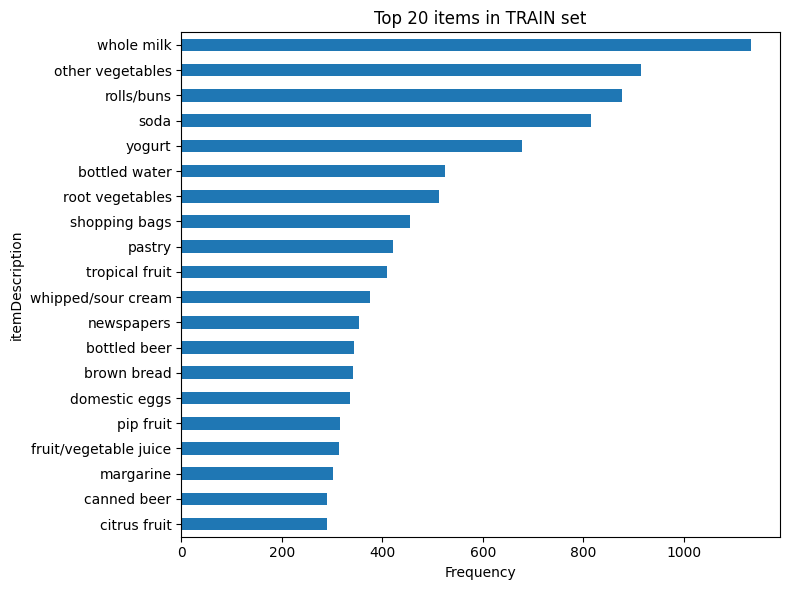

In [60]:
fig, ax = plt.subplots(figsize=(8,6))
top20_train[::-1].plot(kind="barh", ax=ax)
ax.set_title("Top 20 items in TRAIN set")
ax.set_xlabel("Frequency")
plt.tight_layout()
plt.show()

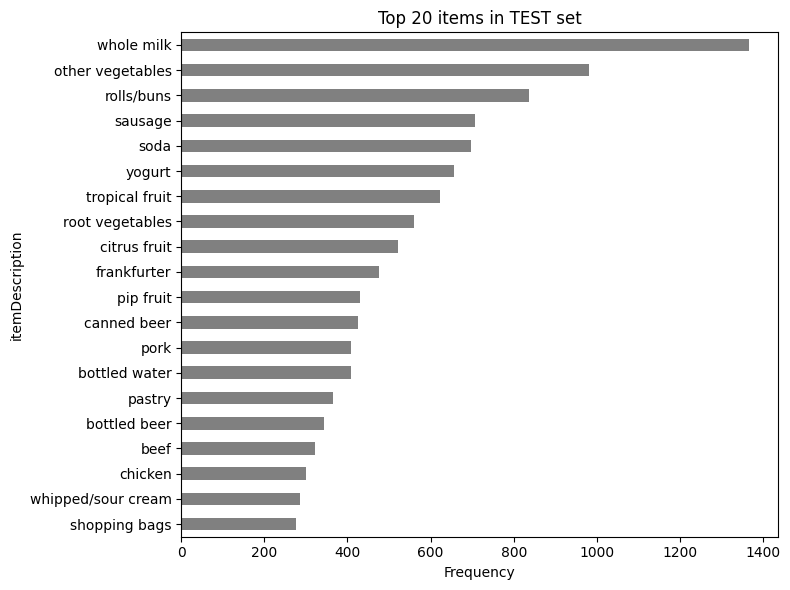

In [61]:
fig, ax = plt.subplots(figsize=(8,6))
top20_test[::-1].plot(kind="barh", ax=ax, color="grey")
ax.set_title("Top 20 items in TEST set")
ax.set_xlabel("Frequency")
plt.tight_layout()
plt.show()

We then proceed to analyzes and visualizes the purchasing patterns in a grocery store dataset across the entire date time. The visualization shows horizontal bar charts of the top 20 most frequently purchased items in both datasets. The findings indicate that basic grocery staples dominate purchases, with "whole milk" being the most purchased item in both years, followed by "other vegetables" and "rolls/buns". The data exhibits a classic long-tail distribution, where a small number of products account for a large proportion of total sales which is a common phenomenon in retail. This pattern is valuable for inventory management and store layout planning, as it helps identify which products should be given prime shelf space and maintained in higher stock levels. 

In [62]:
n_users_train = train_df["user_id"].nunique()
n_users_test  = test_df["user_id"].nunique()
print(f"Unique users in 2014 (train): {n_users_train:,}")
print(f"Unique users in 2015 (test):  {n_users_test:,}")

Unique users in 2014 (train): 3,493
Unique users in 2015 (test):  3,231


In [63]:
items_per_user = train_df.groupby("user_id")["itemDescription"].count()

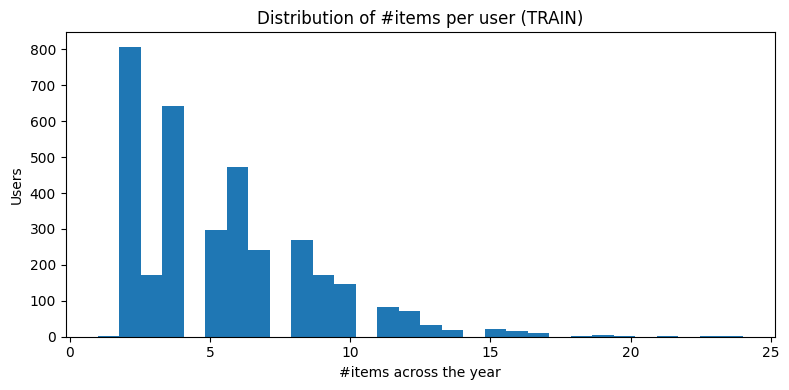

In [64]:
plt.figure(figsize=(8,4))
plt.hist(items_per_user, bins=30)
plt.title("Distribution of #items per user (TRAIN)")
plt.xlabel("#items across the year")
plt.ylabel("Users")
plt.tight_layout()
plt.show()

We find out that there are 3,493 unique users in the training set and 3,231 unique users in the test set. Next, we generate a histogram barplot to see how many distinct items each shoppers grabbed over the whole training year. The result is sharply right-skewed as expected. Around 800 users only shopped 1-3 items all year, whereas around 650 bought 3-4, and this count continues to thin out after 10-20 items which only a fraction of users past 15 items. In other word, the dataset is dominated by light buyers with a long tail of heavy shoppers as we found previously. This will come in handy when we weight similarities such as user-user CF could over-fit those big baskets unless we normalize for basket size or down-weight high-frequency users. 

In [65]:
dow_map = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
train_dow = train_df["day_of_week"].value_counts().sort_index()
test_dow  = test_df["day_of_week"].value_counts().sort_index()

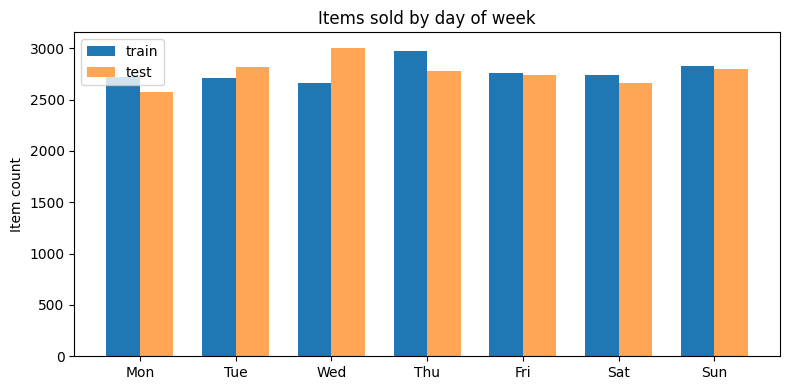

In [66]:
x = np.arange(7)
width = 0.35
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(x - width/2, train_dow.values, width, label="train")
ax.bar(x + width/2, test_dow.values,  width, label="test", alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(dow_map)
ax.set_title("Items sold by day of week")
ax.set_ylabel("Item count")
ax.legend()
plt.tight_layout()
plt.show()

We try to visualize a bar plot to have a better sense of the number of items bought for each day of the week. The observed pattern is pleasantly flat, which means each day hovers around 2.6-3 k items, with Thursday topping 3 k in the 2014 slice and Wednesday doing the same in 2015. Weekends don’t spike much, and Mondays drag only a touch, so demand is fairly even across the week. This is relatively good since it means we can’t blame any accuracy gaps on a weekday mismatch between the two splits. 

In [67]:
train_baskets = (
    train_df
      .groupby(["user_id", "Date"])
      .size()
      .reset_index(name="items_in_basket")
)

In [68]:
baskets_per_user = train_baskets.groupby("user_id").size()

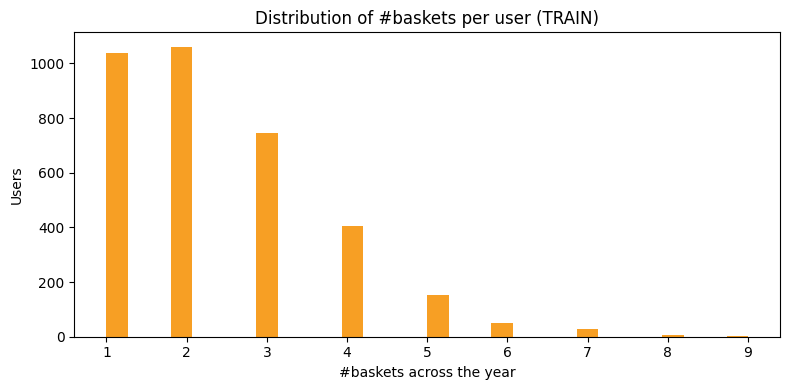

In [69]:
plt.figure(figsize=(8,4))
plt.hist(baskets_per_user, bins=30, color="#F79F24")
plt.title("Distribution of #baskets per user (TRAIN)")
plt.xlabel("#baskets across the year")
plt.ylabel("Users")
plt.tight_layout()
plt.show()

We move on to determining some important features of the dataset we are dealing with. We know that each row of the dataset represents a singular item purchased by a specific user at a specific date, where a given user can buy the same item at multiple occasions hence why in order to have a better understanding of the baskets bought per user, we need to consolidate appropriate rows to generate the basket per transaction dataset. Once we do that, we generate a barplot to help investigate the number of baskets per user throughout the training dataset. We find out that most shoppers are truly occasional. Over half show up just once or twice all year, a further third land in the 3-4-visit range, and only a fraction pushes past five baskets. This is consistent with our findings earlier. That light-touch profile means any user-user CF model will be starved for co-occurrence data on the vast majority of customers. Hence why we might need either strong smoothing, hybrid techniques, or to lean harder on item-based signals for coverage. On the marketing side, this means the shop owners should try to get the one-time shoppers to come back for a second or third visit, instead of putting all your effort into the few people who already shop very often. 

## Frequent Pattern Mininig

In [70]:
class AprioriMiner:
    def __init__(self, min_support=0.005):
        self.min_support = min_support
        self.transactions = None
        self.num_transactions = 0
        self.frequent_itemsets = {}
        self.item_support = {}
    
    # Find all frequent subsets
    def fit(self, transactions):
        """
        Find frequent itemsets using the Apriori algorithm.
        
        Parameters:
        -----------
        transactions : list of lists
            List of transactions, where each transaction is a list of items
        
        Returns:
        --------
        dict
            Dictionary with keys as itemset size and values as list of (itemset, support) tuples
        """
        self.transactions = transactions
        self.num_transactions = len(transactions)
        
        # Step 1: Count support for each individual item
        item_counts = defaultdict(int)
        for transaction in transactions:
            for item in set(transaction):  # Use set to count each item once per transaction
                item_counts[item] += 1
        
        # Filter by minimum support
        min_count = self.min_support * self.num_transactions
        self.item_support = {item: count/self.num_transactions for item, count in item_counts.items() 
                           if count >= min_count}
        
        # Initialize L1 (frequent 1-itemsets)
        L1 = [frozenset([item]) for item in self.item_support.keys()]
        current_L = L1
        k = 1
        
        # Store all frequent itemsets
        self.frequent_itemsets = {
            k: [(itemset, self.item_support[list(itemset)[0]]) for itemset in L1]
        }
        # ========================
        # Main Apriori loop
        while current_L:
            k += 1
            # Generate candidate k-itemsets
            Ck = self._generate_candidates(current_L, k)
            
            if not Ck:
                break  # No candidates generated
                
            # Count support for candidates
            itemset_counts = defaultdict(int)
            for transaction in transactions:
                transaction_set = set(transaction)
                for candidate in Ck:
                    if candidate.issubset(transaction_set):
                        itemset_counts[candidate] += 1
            
            # Filter by minimum support
            Lk = [itemset for itemset, count in itemset_counts.items() 
                 if count >= min_count]
            
            # Store k-itemsets with their support
            if Lk:
                self.frequent_itemsets[k] = [(itemset, itemset_counts[itemset]/self.num_transactions) 
                                           for itemset in Lk]
            
            # Prepare for next iteration
            current_L = Lk
        
        return self.frequent_itemsets
    
    def _generate_candidates(self, prev_itemsets, k):
        """Generate candidate k-itemsets from (k-1)-itemsets"""
        candidates = set()
        
        # For more efficient processing, convert to list of sets
        prev_sets = [set(itemset) for itemset in prev_itemsets]
        
        # For each pair of (k-1)-itemsets
        for i in range(len(prev_sets)):
            for j in range(i+1, len(prev_sets)):
                # Join step
                union = prev_sets[i].union(prev_sets[j])
                if len(union) == k:
                    # Check if all (k-1) subsets are frequent
                    is_valid = True
                    for item in union: # get subset including (k-1) items from current k-item set
                        subset = union - {item}
                        # If one of the subset of the current set is NOT frequent
                        if frozenset(subset) not in prev_itemsets: #[frozenset(s) for s in prev_itemsets]:
                            is_valid = False
                            break
                    
                    if is_valid:
                        candidates.add(frozenset(union)) 
        # Return all sets having k items whose all (k-1) subsets frequent
        return list(candidates)
    
    def generate_rules(self, min_confidence=0.5):
        """
        Generate association rules from frequent itemsets.
        
        Parameters:
        -----------
        min_confidence : float, default=0.5
            Minimum confidence threshold for rules
        
        Returns:
        --------
        list
            List of (antecedent, consequent, support, confidence, lift) tuples
        """
        rules = []
        
        # Helper function to find support for an itemset
        def find_support(itemset):
            k = len(itemset)
            # for k in self.frequent_itemsets:
            for (candidate, support) in self.frequent_itemsets[k]:
                if candidate == itemset:
                    return support
            return 0  # Should not happen for frequent itemsets
        
        # For each k-itemset where k >= 2
        for k in self.frequent_itemsets:
            # Cannot create rules with a set of only 1 item
            if k < 2:
                continue
            # print('hi') 
            for itemset, itemset_support in self.frequent_itemsets[k]:
                
                # Generate all non-empty proper subsets
                subsets = []
                for i in range(1, k):
                    subsets.extend([frozenset(subset) for subset in combinations(itemset, i)])
                # print(subsets)
                # For each subset, create a rule
                for antecedent in subsets: # Take the subsets array as array of all entecedents => itemset - antecedent = consequent set
                    consequent = itemset - antecedent
                    
                    # Skip empty consequents
                    if not consequent:
                        continue
                    
                    # A=>B: Calculate CONFIDENCE P(A, B) / P(A)
                    antecedent_support = find_support(antecedent)
                    confidence = itemset_support / antecedent_support
                    
                    if confidence >= min_confidence:
                        # A= > B: Calculate LIFT P(A, B) /(P(A)*P(B))
                        consequent_support = find_support(consequent)
                        lift = confidence / consequent_support
                        
                        rules.append({
                            'antecedent': list(antecedent),
                            'consequent': list(consequent),
                            'support': itemset_support,
                            'confidence': confidence,
                            'lift': lift
                        })
        
        return rules

In [71]:
class PatternScorer:
    """
    PatternScorer evaluates frequent itemsets from market basket analysis.
    
    This class provides methods to score patterns using various metrics including
    support, lift, recency, and combinations of these metrics. It can also personalize
    recommendations based on user purchase history.
    """
    def __init__(self, transactions, frequent_itemsets, item_support):
        """
        Initialize the PatternScorer with transaction data and frequent itemsets.
        
        Parameters:
        -----------
        transactions : list
            List of transactions where each transaction is a set of items
        frequent_itemsets : dict
            Dictionary mapping k (itemset size) to list of (itemset, support) tuples
        item_support : dict
            Dictionary mapping individual items to their support values
        """
        self.transactions = transactions
        self.frequent_itemsets = frequent_itemsets
        self.item_support = item_support
        self.user_data = None
    
    def add_user_data(self, data):
        """
        Add user-specific data for personalized scoring.
        
        This method processes user transaction data to calculate:
        1. How frequently each user buys each item
        2. When each user last purchased each item
        
        Parameters:
        -----------
        data : DataFrame
            DataFrame containing user purchase history with User_id, itemDescription, and Date columns
        """
        self.user_data = data
        
        # Initialize dictionaries to track user purchase patterns
        # user_item_frequencies: How many times each user bought each item
        self.user_item_frequencies = defaultdict(lambda: defaultdict(int)) 
        #This dictionary stores user's latest date making purchase on each item
        self.user_last_purchase = defaultdict(lambda: defaultdict(str))
        
        # Group data by user
        for _, row in data.iterrows():
            user = row['user_id']
            item = row['itemDescription']
            date = row['Date']
            
            # FOREACH USER FOREACH ITEM: store how many time they purchased that item and the latest purchase date

            # Update frequency
            self.user_item_frequencies[user][item] += 1
            
            # Update last purchase date if needed (if we found a new record of current user purchasing same item but more recent) 
            if item not in self.user_last_purchase[user] or date > self.user_last_purchase[user][item]:
                self.user_last_purchase[user][item] = date
    
    def score_patterns(self, method='combined', user_id=None, top_n=None):
        """
        Score patterns using various metrics.
        
        This method calculates scores for itemsets based on the specified method.
        It can personalize scores for specific users and return only top N results.
        
        Parameters:
        -----------
        method : str, default='combined'
            Scoring method: 'support', 'lift', 'recency', or 'combined'
        user_id : int, optional
            If provided, personalize scores for this user
        top_n : int, optional
            If provided, return only top N patterns
        
        Returns:
        --------
        list
            Scored patterns as (itemset, score) tuples, sorted by score in descending order
        """
        # Create a flat list of all itemsets with their supports
        all_itemsets = []
        if isinstance(self.frequent_itemsets,dict):
            for k in self.frequent_itemsets:
                all_itemsets.extend([(frozenset(itemset), support) for itemset, support in self.frequent_itemsets[k]])
        
        # Apply scoring method

        #support method
        if method == 'support':
            scored_patterns = [(list(itemset), support) for itemset, support in all_itemsets]
        
        #lift method
        elif method == 'lift':
            scored_patterns = []
            for itemset, support in all_itemsets:
                if len(itemset) <= 1:
                    # For single items, just use support 
                    scored_patterns.append((list(itemset), support))
                else:
                    # Calculate average lift for this pattern
                    avg_lift = self._calculate_pattern_lift(itemset, support)
                    # WEIGHT BY SUPPORT==============
                    # score = avg_lift * support
                    score = avg_lift
                    scored_patterns.append((list(itemset), score))
        
        #recency method
        elif method == 'recency':
            if user_id is None or self.user_data is None:
                raise ValueError("User ID and user data required for recency scoring")
            
            scored_patterns = []
            for itemset, support in all_itemsets:
                # Calculate recency score
                recency_score = self._calculate_recency_score(itemset, user_id)
                # Combine with support
                # score = recency_score * support
                score = recency_score
                scored_patterns.append((list(itemset), score))
        
        # combine confidence + lift + recency (using user data)
        elif method == 'combined':
            # Define weights for different factors
            if user_id:
                w_support = 0.2
                w_lift = 0.2
                w_recency = 0.5
                w_frequency = 0.1
            else:
                w_support = 0.4
                w_lift = 0.3
                w_recency = 0
                w_frequency = 0.3
                
            
            scored_patterns = []
            for itemset, support in all_itemsets:
                # Start with support component
                score_components = [support * w_support]
                
                # Add lift component for multi-item patterns
                if len(itemset) > 1:
                    lift = self._calculate_pattern_lift(itemset, support)
                    score_components.append(lift * w_lift)
                else:
                    # For 1-itemsets, still add the weight
                    score_components.append(w_lift)
                
                # Add user-specific components if available
                if user_id is not None and self.user_data is not None:
                    # Recency component
                    recency = self._calculate_recency_score(itemset, user_id)
                    score_components.append(recency * w_recency)
                    
                    # Frequency component
                    frequency = self._calculate_frequency_score(itemset, user_id)
                    score_components.append(frequency * w_frequency)
                else:
                    # Without user data, add the weights
                    score_components.extend([w_recency, w_frequency])
                
                # Calculate final score
                final_score = sum(score_components)
                scored_patterns.append((list(itemset), final_score))
        
        else:
            raise ValueError(f"Unknown scoring method: {method}")
        
        # Sort by score (descending)
        scored_patterns.sort(key=lambda x: x[1], reverse=True)
        
        # Return top N if specified
        if top_n is not None:
            return scored_patterns[:top_n]
        return scored_patterns
    
    def _calculate_pattern_lift(self, pattern, pattern_support):
        """Calculate average lift across all possible rules from this pattern"""
        if len(pattern) <= 1:
            return 1.0  # No meaningful lift for singleton sets
        
        lifts = []
        
        # For each possible rule A -> B from this pattern
        for i in range(1, len(pattern)): #len(antecedent) from 1 to len(pattern) - 1, antecedent cannot be empty 
            for antecedent_items in combinations(pattern, i):
                antecedent = frozenset(antecedent_items)
                consequent = pattern - antecedent
                
                # Find supports
                antecedent_support = self._get_itemset_support(antecedent)
                consequent_support = self._get_itemset_support(consequent)
                
                if antecedent_support > 0 and consequent_support > 0:
                    # A => B, lift = Supp(A,B)/ (Supp(A) * Supp(B)) = Conf(A,B) / Supp(B)
                    confidence = pattern_support / antecedent_support
                    lift = confidence / consequent_support
                    lifts.append(lift)
        
        # Return average lift
        return sum(lifts) / len(lifts) if lifts else 1.0
    
    def _get_itemset_support(self, itemset):
        """Get support for an itemset"""
        if len(itemset) == 1:
            item = list(itemset)[0]
            return self.item_support.get(item, 0)
        
        # Search in frequent itemsets
        for k in self.frequent_itemsets:
            if k == len(itemset):
                for candidate, support in self.frequent_itemsets[k]:
                    if frozenset(candidate) == itemset:
                        return support
        
        return 0  # Not found (not frequent)
    
    def _calculate_recency_score(self, pattern, user_id):
        """Calculate recency score based on how recently user purchased items"""
        if user_id not in self.user_last_purchase:
            return 0  # Default for users with no history
        
        # Get the latest date a purchase was made by a specific user
        latest_date = max(date for user_dates in self.user_last_purchase.values() 
                         for date in user_dates.values())
        
        # Calculate recency for each item in pattern
        recency_scores = []
        # loop to calculate recency score for this pattern
        for item in pattern:
            if item in self.user_last_purchase[user_id]:
                last_purchase = self.user_last_purchase[user_id][item]
                days_since = (latest_date - last_purchase).days
                
                # Convert to a normalized score (higher is more recent)
                # Using exponential decay: e^(-days/30)
                recency = 30/(days_since) #math.exp(-days_since)
                recency_scores.append(recency)
        
        # Return average recency
        return sum(recency_scores) if recency_scores else 0 # / len(recency_scores) 
    
    def _calculate_frequency_score(self, pattern, user_id):
        """Calculate frequency score based on how often user buys these items"""
        if user_id not in self.user_item_frequencies:
            return 0.5  # Default for users with no history
        
        # Find the maximum frequency across all users and items
        max_freq = max(freq for user_freq in self.user_item_frequencies.values() 
                      for freq in user_freq.values())
        
        # Calculate normalized frequency for each item in pattern
        freq_scores = []
        for item in pattern:
            if item in self.user_item_frequencies[user_id]:
                # Normalize by max frequency
                norm_freq = self.user_item_frequencies[user_id][item] / max_freq
                freq_scores.append(norm_freq)
        
        # Return average frequency
        return sum(freq_scores) / len(freq_scores) if freq_scores else 0.5

In [75]:
class FrequentPatternMiner:
    """
    A class for mining and scoring frequent patterns from grocery transaction data.
    """
    
    def __init__(self, min_support=0.005, min_confidence=0.3):
        """
        Initialize the pattern miner.
        
        Parameters:
        -----------
        min_support : float, default=0.005
            Minimum support threshold (between 0 and 1)
        min_confidence : float, default=0.3
            Minimum confidence threshold for association rules
        """
        self.min_support = min_support
        self.min_confidence = min_confidence
        self.apriori_miner = None
        self.pattern_scorer = None
        self.transactions = None
    def prepare_transactions(self, data):
        """
        Convert raw data to transaction format.
        
        Parameters:
        -----------
        data : pandas.DataFrame
            Raw input data
        
        Returns:
        --------
        list of lists
            Transactions in the right format for pattern mining
        """
        # Group by user and date
        transactions = defaultdict(list)
        for _, row in data.iterrows():
            key = (row['user_id'], row['Date'])
            if pd.notna(row['itemDescription']):  # Skip null items
                transactions[key].append(row['itemDescription'])
        
        # Convert to list of lists
        transaction_list = list(transactions.values())
        return transaction_list
    
    def fit(self, data, user_id=None):
        """
        Mine frequent patterns from the data.
        
        Parameters:
        -----------
        data : pandas.DataFrame
            Raw input data
        user_id : int, optional
            If provided, focus on this user's data
        
        Returns:
        --------
        self
        """
        # Prepare transactions
        if user_id is not None:
            # Filter data for specific user
            user_data = data[data['user_id'] == user_id]
            if len(user_data) > 0:
                self.transactions = self.prepare_transactions(user_data)
            else:
                # User has no data, use all data
                self.transactions = self.prepare_transactions(data)
        else:
            self.transactions = self.prepare_transactions(data)
        
        # Run Apriori
        self.apriori_miner = AprioriMiner(min_support=self.min_support)
        frequent_itemsets = self.apriori_miner.fit(self.transactions)
        
        # Create pattern scorer
        self.pattern_scorer = PatternScorer(
            self.transactions, 
            frequent_itemsets, 
            self.apriori_miner.item_support
        )
        self.pattern_scorer.add_user_data(data)
        
        return self
    
    def get_patterns(self, method='combined', user_id=None, top_n=10):
        """
        Get scored patterns.
        
        Parameters:
        -----------
        method : str, default='combined'
            Scoring method: 'support', 'lift', 'recency', or 'combined'
        user_id : int, optional
            If provided, personalize scores for this user
        top_n : int, default=10
            Number of patterns to return
        
        Returns:
        --------
        list
            List of (pattern, score) tuples
        """
        if self.pattern_scorer is None:
            raise ValueError("You must call fit() before get_patterns()")
        
        return self.pattern_scorer.score_patterns(
            method=method, 
            user_id=user_id, 
            top_n=top_n
        )
    
    def get_rules(self, top_n=20):
        """
        Get association rules.
        
        Parameters:
        -----------
        top_n : int, default=20
            Number of rules to return
            
        Returns:
        --------
        list
            List of association rules
        """
        if self.apriori_miner is None:
            raise ValueError("You must call fit() before get_rules()")
        
        rules = self.apriori_miner.generate_rules(min_confidence=self.min_confidence)
        
        # Sort by lift
        sorted_rules = sorted(rules, key=lambda x: x['lift'], reverse=True)
        
        return sorted_rules[:top_n]

In [76]:
miner = FrequentPatternMiner(min_support=0.02/100, min_confidence=0.5)

In [77]:
miner.fit(train_df,user_id=None)

In [78]:
# Get top patterns with combined scoring
top_patterns = miner.get_patterns(method='combined', top_n=15)
print("Top 15 patterns with combined scoring:")
for i, (pattern, score) in enumerate(top_patterns, 1):
    print(f"{i}. {pattern} (score: {score:.4f})")

Top 15 patterns with combined scoring:
1. ['dishes', 'whipped/sour cream', 'frankfurter', 'citrus fruit'] (score: 178.5405)
2. ['vinegar', 'grapes', 'frozen vegetables'] (score: 32.1123)
3. ['dishes', 'frankfurter', 'citrus fruit'] (score: 17.9583)
4. ['soda', 'other vegetables', 'newspapers', 'hard cheese'] (score: 14.5682)
5. ['flower (seeds)', 'honey'] (score: 12.1597)
6. ['dishes', 'whipped/sour cream', 'frankfurter'] (score: 11.5504)
7. ['house keeping products', 'jam'] (score: 10.0790)
8. ['ham', 'rolls/buns', 'pickled vegetables'] (score: 8.2167)
9. ['sugar', 'frankfurter', 'brown bread'] (score: 7.2719)
10. ['cocoa drinks', 'canned fish'] (score: 7.0793)
11. ['soda', 'pickled vegetables', 'ham'] (score: 6.5300)
12. ['pork', 'flower (seeds)', 'whole milk'] (score: 6.0760)
13. ['specialty bar', 'newspapers', 'white bread'] (score: 6.0405)
14. ['oil', 'cookware'] (score: 6.0334)
15. ['processed cheese', 'liver loaf'] (score: 5.8990)


In [79]:
# Get top association rules
top_rules = miner.get_rules(top_n=100)
print("\nTop 10 association rules by lift:")
for i, rule in enumerate(top_rules, 1):
    print(f"{i}. {rule['antecedent']} => {rule['consequent']} "
          f"(support: {rule['support']:.4f}, confidence: {rule['confidence']:.4f}, lift: {rule['lift']:.4f})")


Top 10 association rules by lift:
1. ['dishes', 'citrus fruit'] => ['whipped/sour cream', 'frankfurter'] (support: 0.0002, confidence: 1.0000, lift: 2090.2500)
2. ['whipped/sour cream', 'frankfurter'] => ['dishes', 'citrus fruit'] (support: 0.0002, confidence: 0.5000, lift: 2090.2500)
3. ['dishes', 'whipped/sour cream'] => ['frankfurter', 'citrus fruit'] (support: 0.0002, confidence: 0.5000, lift: 1393.5000)
4. ['frankfurter', 'citrus fruit'] => ['dishes', 'whipped/sour cream'] (support: 0.0002, confidence: 0.6667, lift: 1393.5000)
5. ['dishes', 'frankfurter'] => ['whipped/sour cream', 'citrus fruit'] (support: 0.0002, confidence: 0.6667, lift: 428.7692)
6. ['grapes', 'frozen vegetables'] => ['vinegar'] (support: 0.0002, confidence: 0.6667, lift: 179.8065)
7. ['whipped/sour cream', 'frankfurter', 'citrus fruit'] => ['dishes'] (support: 0.0002, confidence: 1.0000, lift: 112.9865)
8. ['vinegar', 'frozen vegetables'] => ['grapes'] (support: 0.0002, confidence: 1.0000, lift: 101.9634)
9. 

## Collaborative Filtering

In [80]:
unique_users = train_df['user_id'].unique()
unique_items = train_df['itemDescription'].unique()
print("Number of unique users:", len(unique_users))
print("Number of unique items:", len(unique_items))

Number of unique users: 3493
Number of unique items: 167


In [81]:
min_date = train_df['Date'].min()
max_date = train_df['Date'].max()
print(f"Data spans from {min_date.strftime('%Y-%m-%d')} to {max_date.strftime('%Y-%m-%d')}")
print(f"Total days: {(max_date - min_date).days}")

Data spans from 2014-01-01 to 2015-01-20
Total days: 384


In [82]:
min_date = test_df['Date'].min()
max_date = test_df['Date'].max()
print(f"Data spans from {min_date.strftime('%Y-%m-%d')} to {max_date.strftime('%Y-%m-%d')}")
print(f"Total days: {(max_date - min_date).days}")

Data spans from 2015-01-20 to 2015-12-30
Total days: 344


In this version we shift our focus to refining how we generate our base utility matrix and consequently the collaborative filtering functions that will be using it. We start off by examining the exact time difference between the start and the end of the train dataset. The total days range in the train data is 384 days and for test dataset is 344 so it is slightly shorter however we must keep in mind that they are consecutive.

In [83]:
def create_user_item_matrix(df, half_life_days=180):
    """
    Create a user-item matrix incorporating recency information using a configurable half-life parameter.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing user-item interactions with timestamp information
    half_life_days : int, optional
        Half-life parameter in days for the recency decay function (default=180)
        
    Returns:
    --------
    pd.DataFrame
        User-item matrix with recency weights
    """
    # Calculate decay constant lambda based on half-life
    lambda_const = np.log(2) / half_life_days
    
    # Find the most recent date in the dataset
    max_date = df['Date'].max()
    
    # Calculate days difference from the most recent date
    days_diff = (max_date - df['Date']).dt.days
    
    # Add recency information to the dataframe
    df_copy = df.copy()
    df_copy["lambda"] = lambda_const
    df_copy['days_diff'] = days_diff
    df_copy['weight'] = np.exp(-lambda_const * days_diff)
    
    # Create the user-item matrix using pivot table
    user_item_matrix = pd.pivot_table(
        df_copy,
        values='weight',
        index='user_id',
        columns='itemDescription',
        aggfunc='sum',
        fill_value=0
    )
    
    return user_item_matrix

Next, we focus on refining our understanding of the effect of the recency of each purchase. `Faggioli et al (2020)` proposed a method for taking recency in to account by first calculating the user-wise popularity of an item and later inputting that into a recency aware function with an input r, where r is the size of the recency window. The author then would use these probabilistic values to calculate the user based and item based collaborative filtering recommendations. 
$$
\pi_{i}^{u}@r \;=\;
\frac{\displaystyle\sum_{t=[B_u-r]_{+}}^{B_u}
      \llbracket\, i \in b_{u}^{t}\,\rrbracket}
     {\min\!\bigl(r,\,B_u\bigr)}
$$
The literal translation of the author’s approach is that they count in how many of the last r baskets has user u bought item i, then divide by r (or by the users total basket count if they had fewer than r), then construct the utility matrix for all users with this formula for each appropriate cell, then look at people who shop like the target user. 
$$
\hat{r}_{i}^{u} \;=\;
\sum_{v \in \mathcal{U}}
      w(u,v)^{q}\,\pi_{i}^{v}.
$$
If they are very similar, borrow their most-frequent items form the utility matrix that was generated and use them as weights to calculate the weighted average to score the items they bought. There are a couple of pitfalls in this approach that would not ideally work without dataset, the most important one being that the paper uses `Dunnhumby` and `Instacart`, however the resulting utility matrix for our existing dataset would turn out to be quite sparse since all the data that we have spans only two years in total with majority of the transactions being from non-frequent users. Due to this, limiting the recency window by a strict value of `r` would not provide a strong enough signal for our recommendation system to effectively produce high ranking recommendations. What we propose is a half-life exponential decay, with formula
$$
\pi_{i}^{\,v}(\lambda) \;=\;
\sum_{k=1}^{N_{(v,i)}} e^{-\lambda\,\Delta t_{(v,i,k)}}
$$

$$
\hat{r}_{i}^{\,u}(\lambda) \;=\;
\sum_{v \in \mathcal{U}}
      \bigl[w(u,v)\bigr]^{q}\,
      \pi_{i}^{\,v}(\lambda).
$$
This formula translates to looking at ALL past transactions, but shrink each one’s importance the older it is. Lambda here is the decay factor calculated based on the half-life we determine. To model recency decay in a recommendation system, we calculate λ using the following formula: 

$$
\Lambda = \frac{\ln(2)}{\text{HALF\_LIFE\_DAYS}}
$$

If we for example set the half-life to 180 days, that would mean that 
Items from 180 days ago have weight: 0.500
Items from 360 days ago have weight: 0.250
Items from 540 days ago have weight: 0.125
and so on. This is one of the hyperparameters that we can tune during our hyperparameter optimization on the validation set.
In version 04 we start off by first modularizing the utility matrix creation into a separate function that can take the half-life as input dynamically for a more robust testing and evaluation setup later compared to version 3. Same as before we calculate the decay first based on the input half-life in days. Then find the max date of the current dataset we are working with to be used for calculating the difference in days, or delta t. Next we add helper recency columns to a copy of our datafram and using that we generate the user item interaction utility matrix.

In [84]:
def compute_similarities(matrix, method='user'):
    """
    Compute similarities between users or items using cosine similarity.
    
    Parameters:
    -----------
    matrix : pd.DataFrame
        User-item matrix 
    method : str, optional
        Type of similarity to compute - either 'user' or 'item' (default='user')
        
    Returns:
    --------
    pd.DataFrame
        Similarity matrix
    """
    if method == 'user':
        sim_matrix = cosine_similarity(matrix)
        return pd.DataFrame(sim_matrix, index=matrix.index, columns=matrix.index)
    else:  # item-item
        sim_matrix = cosine_similarity(matrix.T)
        return pd.DataFrame(sim_matrix, index=matrix.columns, columns=matrix.columns)

Next we choose to continue `cosine_similarity` library function from `sklearn` instead of using our own implemented version mainly since the library function calculates the resulting similarity matrix much more efficient than the our pervious implementation in version 1 and 2.

In [85]:
def generate_recommendations(user_item_matrix, sim_matrix, user_id=None, method='user', top_n=5):
    '''
    Generate recommendations using collaborative filtering based on either user-user or item-item similarity

    Parameters:
    -----------
    user_item_matrix : pd.DataFrame
        Matrix containing user-item interactions with recency weights
    sim_matrix : pd.DataFrame 
        Pre-computed similarity matrix (either user-user or item-item)
    user_id : int
        ID of the user to generate recommendations for
    method : str, optional
        Type of collaborative filtering - either 'user' or 'item' (default='user')
    top_n : int, optional
        Number of recommendations to return (default=5)

    Returns:
    --------
    pd.Series
        Series containing top-n recommended items with their scores
        Returns None if user_id not found or no recommendations possible
    '''
    
    if method == 'user':
        if user_id not in user_item_matrix.index:
            return None
        similar_scores = sim_matrix.loc[user_id]
        similar_users = similar_scores.nlargest(top_n + 1).index[1:]
        
        user_items = user_item_matrix.loc[similar_users]
        similar_user_weights = similar_scores[similar_users].values.reshape(-1, 1)
        weight_sum = similar_user_weights.sum()
        
        weighted_items = pd.Series(
            (user_items.values * similar_user_weights).sum(axis=0) / weight_sum,
            index=user_item_matrix.columns
        )
        
        user_items = user_item_matrix.loc[user_id]
        weighted_items[user_items > 0] = 0
        
        return weighted_items.nlargest(top_n)

    else:   # method == 'item'
        if user_id not in user_item_matrix.index:
            return None
        
        user_vec = user_item_matrix.loc[user_id]
        bought_items = user_vec[user_vec > 0]
        candidates = user_vec[user_vec == 0].index

        scores = {}

        for target in candidates:
            sims = sim_matrix.loc[target, bought_items.index]
            sims_top = sims[sims > 0].sort_values(ascending=False).head(top_n)
            if sims_top.empty:
                continue

            sim_vals   = sims_top.values
            purchase_w = bought_items[sims_top.index].values

            scores[target] = np.dot(sim_vals, purchase_w) / sim_vals.sum()

        if not scores:
            return None
        
        return (pd.Series(scores).sort_values(ascending=False).head(top_n))

Moving on, we redefine our recommendation function and fix some of the issue from version 1 and 2. In the perviosu versions, first of all we had defined two sepeate CF functions for user-user and item-item cases, whereas this can be flattend into one single function that handles both of them. Next, initially we were only taking the average of the applied weights of the similar users/items, which according to class lecture 10 notes, is wrong and we need to apply a weighted average and basically divide the resulting sum by the sum of the similar user/item similarity weights. Once we fix these issues, the overall structure of the function remains the same. For the case of user-user we first check if the specific user_id exists and return and error if nothing found. Next we look up the similarity scores between the target user and all the other users. We pick the top K most similar user to our target, which it's 5 here. After that we find the weights of the items that these similar users have bought. We then calculate a weighted average for each item by multiplying the weights of the items bought by the similar users by the similarity weigths between them and the target user. Then sum them up and divide them by the sum of the similarity weights we found earlier. Finally we remove all the items from this that our target user has already bought by setting their scores to zero again. Once that’s done we pick the top N items from the sorted list of the results which here is 5 items that are recommended. With the case of item-item, we again check the validity of the user_id passed to the function. Next we grab all the item weights the user has bought and also the items the user has not bought yet as candidate items. We initialize an empty dictionary called `scores` and we start iterating through all the candidate items to perform the calculations. For each candidate item, we look at how similar this item is to each item the user has bought using the similarity matrix specific for the item-item.  Next we keep the topN positive values, which 5 in our case, and if there are no positive values for this candidate, we skip it. This is mainly because, as per the explored example during lecture 10, we cannot consider the positive similarity weights for the items that the user themselves haven’t bought yet since doing so would lead to a multiplication by a NaN value. Moving on, we calculate the score for the target item by multiplying the similarity weight between the target item and the rest of the items we obtained by the weight score of the target users purchase, sum the up and divide by the sum of the similarity weights of the similar items we obtained and we populate the dictionary with our results. Finally, we look through the resulting scores dictionary to grab the topK, or top5 in our case, highest scores as our item-item recommendations. The intuitive way to think about it is that, item A is often bought similar to item B and item C, so we can our target user’s weighted recency rating for items B and C to with what strength would our target user buy item A.

In [86]:
rules_df = pd.read_excel('association_rules.xlsx')

In [87]:
def get_specialized_cf_recommendations(rules_df, user_item_matrix, user_id, top_n=5):
    """
    Generate specialized collaborative filtering recommendations using association rules and user-item matrix
    
    Parameters:
    -----------
    rules_df : pd.DataFrame
        DataFrame containing association rules with columns: antecedent, consequent, support, confidence, lift
    user_item_matrix : pd.DataFrame
        User-item matrix incorporating recency information
    user_id : int
        ID of the user to generate recommendations for
    top_n : int, optional
        Number of recommendations to return (default=5)
        
    Returns:
    --------
    list
        List of top-n recommended items sorted by score
    """
    if user_id not in user_item_matrix.index:
        return []
    user_items = set(user_item_matrix.columns[user_item_matrix.loc[user_id] > 0])
    recommendations = defaultdict(float)
    rules_df['antecedent_set'] = rules_df['antecedent'].apply(lambda x: set(x.split(', ')))
    rules_df['consequent_set'] = rules_df['consequent'].apply(lambda x: set(x.split(', ')))
    
    for _, rule in rules_df.iterrows():
        antecedent_items = rule['antecedent_set']
        consequent_items = rule['consequent_set']
        
        overlap = antecedent_items.intersection(user_items)
        if len(overlap) > 0:
            overlap_score = len(overlap) / len(antecedent_items)
            
            for item in consequent_items:
                if item not in user_items:
                    recency_score = user_item_matrix.loc[user_id, list(overlap)].mean() if len(overlap) > 0 else 0
                    rule_score = rule['confidence'] * rule['lift'] * overlap_score
                    final_score = rule_score * (1 + recency_score)
                    recommendations[item] += final_score
                    
    sorted_recommendations = sorted(
        recommendations.items(),
        key=lambda x: x[1],
        reverse=True
    )
    
    return sorted_recommendations[:top_n]

We then shift our focus to developing the collaborative filtering function that works based on the generated input from task 1. For now before integrating the rest of the tasks, we obtain a .xlsx file from task 1 as input. The file includes numerous rows of generated association rules that can be used input for our CF function. Delving deeper into the function’s logic, it starts off by getting the association rules, user utility matrix, user id and top K recommendation as input. It gets the target user’s current items that have a non-zero scoring on the matrix and initializes a dictionary for keeping track of the recommendations. Next for it cleans up the input data columns of antecedent and consequent to be easily accessible and readable for the code. 
$$
\text{antecedent}(X) \Rightarrow \text{consequent}(Y)
$$
The function then iterates through all the rows of the rules, grabbing both the antecedent and consequent and looking up the intersection of the target users utility scoring matrix row with the antecedent. What this does is basically calculate the overlap of the items that the user has bought throughout their transaction history with any cases of the antecedent present on the left hand side of the association rules. If more items from the target user’s purchases history can be found on the left hand side of the rule all together as an antecedent, along with a strong lift, that means that we can grab the consequent of that rule and score it more strongly. To keep track of the overlap score, the function divides the number of items that exactly overalp by the total number of the antecedents on the left hand side. Once this is done, and for example we know based on the left hand side that this rule is highly relevant to our target user, we look to the right hand side of the equation for the consequent, however we must ensure that the items present are not in the user’s purchase history since we don’t want to recommend something they have already bought. Once this is handled, for each item in the rule’s consequent that the user hasn’t already bought, the function builds a score: `recency_score` is the average of the user’s recency-weighted values for the overlapping items (reflecting how recently the user bought things that trigger the rule). `rule_score` is the rule’s own strength (confidence * lift) adjusted by overlap_score. `final_score` multiplies rule_score by (1 + recency_score) so that recent behaviour boosts the recommendation. That final_score is added into the running total for the candidate item in recommendations. After every rule has been processed, the dictionary is sorted from highest to lowest score, and the function returns the first `top_n` entries as the recommended items.

In [88]:
def get_most_popular_items(df, top_n=10):
    """
    Get the most popular items based on frequency of purchase
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing purchase data
    top_n : int, optional
        Number of popular items to return (default=10)
        
    Returns:
    --------
    list
        List of top_n most popular items
    """
    item_counts = df['itemDescription'].value_counts()
    return item_counts.nlargest(top_n).index.tolist()

Next we develop a function to handle the test case edge case for when a user is a fresh costumer and has no shopping history. The function simply retunrs the top k list of the most bought items based on the ` itemDescription` in the dataset.

In [89]:
def chronological_train_validation_split(df, validation_days=30):
    """
    Split data chronologically into training and validation sets.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing transaction data with datetime column 'Date'
    validation_days : int, optional
        Number of days to use for validation (default=30)
        
    Returns:
    --------
    tuple
        (train_df, validation_df) - DataFrames for training and validation
    """
    df_sorted = df.sort_values('Date')
    
    max_date = df_sorted['Date'].max()
    cutoff_date = max_date - timedelta(days=validation_days)
    
    train_df = df_sorted[df_sorted['Date'] <= cutoff_date]
    validation_df = df_sorted[df_sorted['Date'] > cutoff_date]
    
    return train_df, validation_df

In [90]:
def precision_at_k(recommended_items, actual_items, k=10):
    """
    Calculate precision@k metric
    
    Parameters:
    -----------
    recommended_items : list
        List of recommended items
    actual_items : list
        List of actual items user interacted with
    k : int, optional
        Number of recommendations to consider (default=10)
        
    Returns:
    --------
    float
        Precision@k value
    """
    if len(recommended_items) == 0:
        return 0.0
    
    # Take only top-k recommendations
    top_k = recommended_items[:k]
    
    # Count relevant items in top-k
    hits = len(set(top_k) & set(actual_items))
    
    # Precision@k = # of relevant items in top-k / k
    return hits / min(k, len(top_k))

In [91]:
def recall_at_k(recommended_items, actual_items, k=10):
    """
    Calculate recall@k metric
    
    Parameters:
    -----------
    recommended_items : list
        List of recommended items
    actual_items : list
        List of actual items user interacted with
    k : int, optional
        Number of recommendations to consider (default=10)
        
    Returns:
    --------
    float
        Recall@k value
    """
    if len(actual_items) == 0 or len(recommended_items) == 0:
        return 0.0
    
    # Take only top-k recommendations
    top_k = recommended_items[:k]
    
    # Count relevant items in top-k
    hits = len(set(top_k) & set(actual_items))
    
    # Recall@k = # of relevant items in top-k / # of relevant items
    return hits / len(actual_items)


In [92]:
def hit_rate(recommended_items_list, actual_items_list):
    """
    Calculate hit rate across all users
    
    Parameters:
    -----------
    recommended_items_list : list of lists
        List containing recommended items for each user
    actual_items_list : list of lists
        List containing actual items for each user
        
    Returns:
    --------
    float
        Hit rate value
    """
    hits = 0
    for i in range(len(recommended_items_list)):
        if len(set(recommended_items_list[i]) & set(actual_items_list[i])) > 0:
            hits += 1
    
    return hits / len(recommended_items_list)

In [93]:
def ndcg_at_k(recommended_items, actual_items, k=10):
    """
    Calculate Normalized Discounted Cumulative Gain at k
    
    Parameters:
    -----------
    recommended_items : list
        List of recommended items
    actual_items : list
        List of actual items user interacted with
    k : int, optional
        Number of recommendations to consider (default=10)
        
    Returns:
    --------
    float
        NDCG@k value
    """
    if len(actual_items) == 0 or len(recommended_items) == 0:
        return 0.0
    
    # Take only top-k recommendations
    top_k = recommended_items[:k]
    
    # Calculate DCG
    dcg = 0
    for i, item in enumerate(top_k):
        if item in actual_items:
            # Using binary relevance (1 if relevant, 0 if not)
            # Position is i+1 (1-indexed)
            dcg += 1.0 / np.log2(i + 2)  # +2 because i is 0-indexed and log_2(1) is 0
    
    # Calculate IDCG
    # For IDCG, we assume the best possible ordering:
    # all relevant items at the top positions
    num_relevant = min(len(actual_items), k)
    idcg = sum([1.0 / np.log2(i + 2) for i in range(num_relevant)])
    
    # Avoid division by zero
    if idcg == 0:
        return 0.0
    
    # NDCG = DCG / IDCG
    return dcg / idcg

In [94]:
def average_precision_at_k(recommended_items, actual_items, k=10):
    """
    Calculate Average Precision at k
    
    Parameters:
    -----------
    recommended_items : list
        List of recommended items
    actual_items : list
        List of actual items user interacted with
    k : int, optional
        Number of recommendations to consider (default=10)
        
    Returns:
    --------
    float
        Average Precision at k
    """
    if len(actual_items) == 0 or len(recommended_items) == 0:
        return 0.0
    
    # Take only top-k recommendations
    top_k = recommended_items[:k]
    
    hits = 0
    sum_precisions = 0
    
    for i, item in enumerate(top_k):
        if item in actual_items:
            hits += 1
            # Precision at current position
            precision_at_i = hits / (i + 1)
            sum_precisions += precision_at_i
    
    # Average precision = sum of precisions / number of relevant items
    return sum_precisions / min(len(actual_items), k)

In [95]:
def evaluate_recommender(train_df, validation_df, half_life_days, method='user', rules_df=None, top_n=10, k=5):
    """
    Evaluate recommender system performance using various metrics
    
    Parameters:
    -----------
    train_df : pd.DataFrame
        Training data
    validation_df : pd.DataFrame
        Validation data
    half_life_days : int or list
        Half-life parameter(s) to evaluate
    method : str, optional
        Recommendation method - 'user', 'item', or 'association' (default='user')
    rules_df : pd.DataFrame, optional
        Association rules data (required if method='association')
    top_n : int, optional
        Number of recommendations to generate (default=10)
    k : int, optional
        Parameter for precision@k, recall@k, etc. (default=5)
        
    Returns:
    --------
    dict
        Dictionary containing evaluation metrics
    """
    # Convert half_life_days to list if it's a single value
    if not isinstance(half_life_days, list):
        half_life_days = [half_life_days]
    
    # Get unique users in validation set
    val_users = validation_df['user_id'].unique()
    
    # Group validation data by user to get actual items
    val_user_items = validation_df.groupby('user_id')['itemDescription'].apply(list)
    
    # Get popular items for cold-start users
    popular_items = get_most_popular_items(train_df, top_n=top_n)
    
    results = {}
    
    for half_life in half_life_days:
        # Create user-item matrix with current half-life
        user_item_matrix = create_user_item_matrix(train_df, half_life_days=half_life)
        
        # Compute similarity matrices
        if method == 'user' or method == 'item':
            sim_matrix = compute_similarities(user_item_matrix, method=method)
        
        # Collect recommendations and actual items for all users
        all_recommendations = []
        all_actuals = []
        
        for user_id in val_users:
            # Get actual items for this user
            if user_id in val_user_items:
                actual_items = val_user_items[user_id]
            else:
                # Skip users with no validation items
                continue
            
            # Generate recommendations
            if method == 'user' or method == 'item':
                # Check if user is in training data
                if user_id in user_item_matrix.index:
                    recs = generate_recommendations(
                        user_item_matrix, 
                        sim_matrix, 
                        user_id, 
                        method=method, 
                        top_n=top_n
                    )
                    if recs is not None:
                        recommended_items = recs.index.tolist()
                    else:
                        recommended_items = popular_items
                else:
                    # Cold-start: recommend popular items
                    recommended_items = popular_items
            
            elif method == 'association':
                if rules_df is None:
                    raise ValueError("rules_df must be provided for association method")
                
                if user_id in user_item_matrix.index:
                    recs = get_specialized_cf_recommendations(
                        rules_df, 
                        user_item_matrix, 
                        user_id, 
                        top_n=top_n
                    )
                    if recs:
                        recommended_items = [item for item, _ in recs]
                    else:
                        recommended_items = popular_items
                else:
                    # Cold-start: recommend popular items
                    recommended_items = popular_items
            
            all_recommendations.append(recommended_items)
            all_actuals.append(actual_items)
        
        # Calculate metrics
        precisions = []
        recalls = []
        ndcgs = []
        avg_precisions = []
        
        for recs, acts in zip(all_recommendations, all_actuals):
            precisions.append(precision_at_k(recs, acts, k))
            recalls.append(recall_at_k(recs, acts, k))
            ndcgs.append(ndcg_at_k(recs, acts, k))
            avg_precisions.append(average_precision_at_k(recs, acts, k))
        
        # Average metrics
        results[half_life] = {
            'precision@k': np.mean(precisions),
            'recall@k': np.mean(recalls),
            'ndcg@k': np.mean(ndcgs),
            'map@k': np.mean(avg_precisions),
            'hit_rate': hit_rate(all_recommendations, all_actuals)
        }
    
    return results

In [96]:
def tune_half_life(train_df, validation_df, half_life_range, method='user', rules_df=None, top_n=10, k=5):
    """
    Tune half-life parameter and find optimal value
    
    Parameters:
    -----------
    train_df : pd.DataFrame
        Training data
    validation_df : pd.DataFrame
        Validation data
    half_life_range : list
        Range of half-life values to evaluate
    method : str, optional
        Recommendation method - 'user', 'item', or 'association' (default='user')
    rules_df : pd.DataFrame, optional
        Association rules data (required if method='association')
    top_n : int, optional
        Number of recommendations to generate (default=10)
    k : int, optional
        Parameter for precision@k, recall@k, etc. (default=5)
        
    Returns:
    --------
    tuple
        (best_half_life, metrics_dict) - Best half-life value and dictionary of all metrics
    """
    results = evaluate_recommender(
        train_df, 
        validation_df, 
        half_life_range, 
        method=method, 
        rules_df=rules_df, 
        top_n=top_n, 
        k=k
    )
    
    # Find best half-life based on NDCG (could be any metric)
    best_half_life = max(results.keys(), key=lambda x: results[x]['ndcg@k'])
    
    return best_half_life, results

In [97]:
def compare_methods(train_df, validation_df, half_life, rules_df=None, top_n=10, k=5):
    """
    Compare different recommendation methods
    
    Parameters:
    -----------
    train_df : pd.DataFrame
        Training data
    validation_df : pd.DataFrame
        Validation data
    half_life : int
        Half-life parameter value to use
    rules_df : pd.DataFrame, optional
        Association rules data
    top_n : int, optional
        Number of recommendations to generate (default=10)
    k : int, optional
        Parameter for precision@k, recall@k, etc. (default=5)
        
    Returns:
    --------
    dict
        Dictionary containing evaluation metrics for each method
    """
    methods = ['user', 'item']
    if rules_df is not None:
        methods.append('association')
    
    results = {}
    
    for method in methods:
        method_results = evaluate_recommender(
            train_df, 
            validation_df, 
            half_life, 
            method=method, 
            rules_df=rules_df, 
            top_n=top_n, 
            k=k
        )
        results[method] = method_results[half_life]
    
    return results

In [98]:
def test_on_test_set(train_df, test_df, best_half_life, best_method, rules_df=None, top_n=10, k=5):
    """
    Test recommender system on test set using best parameters
    
    Parameters:
    -----------
    train_df : pd.DataFrame
        Training data
    test_df : pd.DataFrame
        Test data
    best_half_life : int
        Best half-life parameter value
    best_method : str
        Best recommendation method
    rules_df : pd.DataFrame, optional
        Association rules data
    top_n : int, optional
        Number of recommendations to generate (default=10)
    k : int, optional
        Parameter for precision@k, recall@k, etc. (default=5)
        
    Returns:
    --------
    dict
        Dictionary containing test metrics
    """
    return evaluate_recommender(
        train_df, 
        test_df, 
        best_half_life, 
        method=best_method, 
        rules_df=rules_df, 
        top_n=top_n, 
        k=k
    )[best_half_life]


In [99]:
print("Loading and preprocessing data...")
# Load datasets
train_path = 'Groceries data train.csv'
test_path = 'Groceries data test.csv'
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# Preprocessing
train_df = train_df.rename(columns={"User_id": "user_id"})
train_df["Date"] = pd.to_datetime(train_df["Date"], format='%d/%m/%Y')
test_df["Date"] = pd.to_datetime(test_df["Date"], format='%d/%m/%Y')

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("\nNumber of unique users:", len(train_df['user_id'].unique()))
print("Number of unique items:", len(train_df['itemDescription'].unique()))

# Load association rules
print("\nLoading association rules...")
rules_df = pd.read_excel('association_rules.xlsx')

# Split training data into train and validation
print("\nSplitting data chronologically into train and validation sets...")
train_subset, validation_df = chronological_train_validation_split(train_df, validation_days=30)
print(f"Train subset shape: {train_subset.shape}")
print(f"Validation shape: {validation_df.shape}")

# Tune half-life parameter
print("\nTuning half-life parameter...")
# Define half-life values to evaluate (in days)
half_life_range = [7, 14, 30, 60, 90, 180, 365]

# Test for user-based CF
print("\nEvaluating user-based collaborative filtering...")
best_hl_user, user_results = tune_half_life(
    train_subset, validation_df, half_life_range, method='user', top_n=10, k=5
)
print(f"Best half-life for user-based CF: {best_hl_user} days")
print("Results for best half-life:")
for metric, value in user_results[best_hl_user].items():
    print(f"  {metric}: {value:.4f}")

# Plot metrics for user-based CF
# plot_all_metrics(user_results)

# Test for item-based CF
print("\nEvaluating item-based collaborative filtering...")
best_hl_item, item_results = tune_half_life(
    train_subset, validation_df, half_life_range, method='item', top_n=10, k=5
)
print(f"Best half-life for item-based CF: {best_hl_item} days")
print("Results for best half-life:")
for metric, value in item_results[best_hl_item].items():
    print(f"  {metric}: {value:.4f}")

# Plot metrics for item-based CF
# plot_all_metrics(item_results)

# Test for association rule-based recommendations
print("\nEvaluating association rule-based recommendations...")
best_hl_assoc, assoc_results = tune_half_life(
    train_subset, validation_df, half_life_range, method='association', 
    rules_df=rules_df, top_n=10, k=5
)
print(f"Best half-life for association rules: {best_hl_assoc} days")
print("Results for best half-life:")
for metric, value in assoc_results[best_hl_assoc].items():
    print(f"  {metric}: {value:.4f}")

# Plot metrics for association rule-based recommendations
# plot_all_metrics(assoc_results)

# Compare methods using their best half-life values
print("\nComparing methods with their best half-life values...")
best_methods = {
    'user': (best_hl_user, user_results[best_hl_user]),
    'item': (best_hl_item, item_results[best_hl_item]),
    'association': (best_hl_assoc, assoc_results[best_hl_assoc])
}

# Find the best method based on NDCG (could use any metric)
best_method = max(best_methods.keys(), key=lambda m: best_methods[m][1]['ndcg@k'])
best_half_life = best_methods[best_method][0]

print(f"\nBest method: {best_method}-based with half-life of {best_half_life} days")
print(f"Metrics for best method:")
for metric, value in best_methods[best_method][1].items():
    print(f"  {metric}: {value:.4f}")

# Evaluate on test set using best method and half-life
print("\nEvaluating on test set using best method and half-life...")
test_results = test_on_test_set(
    train_df, test_df, best_half_life, best_method, 
    rules_df=rules_df if best_method == 'association' else None,
    top_n=10, k=5
)

print("\nTest set results:")
for metric, value in test_results.items():
    print(f"  {metric}: {value:.4f}")

# Example recommendations for a user
user_id = 1004  # Example user
print(f"\nGenerating recommendations for user {user_id} using best method...")

# Create user-item matrix with best half-life
user_item_matrix = create_user_item_matrix(train_df, half_life_days=best_half_life)

# Generate recommendations based on best method
if best_method == 'user' or best_method == 'item':
    sim_matrix = compute_similarities(user_item_matrix, method=best_method)
    recommendations = generate_recommendations(
        user_item_matrix, sim_matrix, user_id, 
        method=best_method, top_n=10
    )
    if recommendations is not None:
        recommended_items = [(item, score) for item, score in recommendations.items()]
    else:
        recommended_items = [(item, 1.0) for item in get_most_popular_items(train_df)]

elif best_method == 'association':
    recommended_items = get_specialized_cf_recommendations(
        rules_df, user_item_matrix, user_id, top_n=10
    )
    if not recommended_items:
        recommended_items = [(item, 1.0) for item in get_most_popular_items(train_df)]

print(f"\nTop 10 recommendations for user {user_id} using {best_method}-based CF with half-life {best_half_life}:")
for item, score in recommended_items[:10]:
    print(f"- {item}: {score:.4f}")


Loading and preprocessing data...
Train shape: (19382, 7)
Test shape: (19383, 7)

Number of unique users: 3493
Number of unique items: 167

Loading association rules...

Splitting data chronologically into train and validation sets...
Train subset shape: (17818, 7)
Validation shape: (1564, 7)

Tuning half-life parameter...

Evaluating user-based collaborative filtering...
Best half-life for user-based CF: 180 days
Results for best half-life:
  precision@k: 0.0693
  recall@k: 0.1206
  ndcg@k: 0.1076
  map@k: 0.0684
  hit_rate: 0.4451

Evaluating item-based collaborative filtering...
Best half-life for item-based CF: 180 days
Results for best half-life:
  precision@k: 0.0242
  recall@k: 0.0418
  ndcg@k: 0.0377
  map@k: 0.0247
  hit_rate: 0.1458

Evaluating association rule-based recommendations...
Best half-life for association rules: 30 days
Results for best half-life:
  precision@k: 0.0797
  recall@k: 0.1269
  ndcg@k: 0.1116
  map@k: 0.0706
  hit_rate: 0.5189

Comparing methods with th

In [41]:
best_method

'association'

In [42]:
best_half_life

30